In [1]:
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
# Get the project root directory
project_root = Path.cwd()
sys.path.append(str(project_root.parent))

from notebook_imports import *

In [3]:
# Set project directories using configuration
home_dir = str(config.PROJECT_ROOT)
data_dir = str(config.DATA_DIR)
resources_dir = str(config.RESOURCES_DIR)
results_dir = str(config.RESULTS_03_DIR)
figures_dir = str(config.FIGURES_03_DIR)

In [4]:
def _load_sciplex_outcomes_csv(cell_line: str, stem: str) -> pd.DataFrame | None:
    candidates = [stem]
    if 'CPA' in stem:
        candidates.append(stem.replace('CPA', 'cpa'))
    for name in candidates:
        fpath = os.path.join(results_dir, f'sciplex{cell_line}_{name}.csv')
        if os.path.exists(fpath):
            return pd.read_csv(fpath)
    print(f'Missing SciPlex file: sciplex{cell_line}_{stem}.csv')
    return None


def process_performances(cell_line):
    frames = []
    for stem, model in [
        ('GEARS_outcomes', 'GEARS'),
        ('scfoundation_outcomes', 'scFoundation'),
        ('CPA_outcomes', 'CPA'),
        ('no_effect_outcomes', 'No effect'),
        ('average_effect_outcomes', 'Average effect'),
    ]:
        df = _load_sciplex_outcomes_csv(cell_line, stem)
        if df is None:
            continue
        df['model'] = model
        frames.append(df)

    if not frames:
        raise FileNotFoundError(
            f'No SciPlex outcome files found for {cell_line} in {results_dir}. '
            'Run evaluate_predictions_sciplex.py first.'
        )

    outcomes = pd.concat(frames, axis=0, ignore_index=True).dropna(subset=['value'])
    outcomes['cell_type_condition'] = outcomes['cell_type'] + '_' + outcomes['condition']
    outcomes['dataset'] = 'SciPlex3 dataset'
    return outcomes


def process_mcfarland_performances(suffix: str = '') -> pd.DataFrame:
    """Load McFarland evaluation CSVs (suffix '' or '_systema')."""
    file_map = {
        'CPA': f'mcfarland_CPA{suffix}_outcomes.csv',
        'GEARS': f'mcfarland_GEARS{suffix}_outcomes.csv',
        'scFoundation': f'mcfarland_scFoundation{suffix}_outcomes.csv',
        'No effect': f'mcfarland_no_effect{suffix}_outcomes.csv',
        'Average effect': f'mcfarland_average_effect{suffix}_outcomes.csv',
    }
    frames = []
    for model, filename in file_map.items():
        fpath = os.path.join(results_dir, filename)
        if not os.path.exists(fpath):
            print(f'Skipping missing McFarland file: {filename}')
            continue
        df = pd.read_csv(fpath)
        df['model'] = model
        frames.append(df)
    if not frames:
        raise FileNotFoundError('No McFarland outcome files found in results_dir')

    outcomes = pd.concat(frames, axis=0, ignore_index=True).dropna(subset=['value'])
    outcomes['dataset'] = 'McFarland dataset'
    outcomes['cell_type'] = outcomes['cell_line']
    outcomes['cell_type_condition'] = outcomes['cell_line'] + '_' + outcomes['condition']
    return outcomes


## Profile prediction evaluation

One figure per metric (figsize 20×7): SciPlex and McFarland side by side on a single row.


In [5]:
mcf7_outcomes = process_performances('mcf7')
a549_outcomes = process_performances('a549')
k562_outcomes = process_performances('k562')

sciplex_outcomes = pd.concat([mcf7_outcomes, a549_outcomes, k562_outcomes], axis=0, ignore_index=True)
mcfarland_outcomes = process_mcfarland_performances(suffix='')

all_outcomes = pd.concat([sciplex_outcomes, mcfarland_outcomes], axis=0, ignore_index=True)

print('Rows per dataset / model:')
print(all_outcomes.groupby(['dataset', 'model']).size().unstack(fill_value=0))


Rows per dataset / model:
model              Average effect   CPA  GEARS  No effect  scFoundation
dataset                                                                
McFarland dataset            3960  3960   1304       3960          1460
SciPlex3 dataset              924   924    924        924           924


Save.

In [6]:
sciplex_outcomes.to_csv(os.path.join(results_dir, 'sciplex_all_outcomes.csv'), index=False)
mcfarland_outcomes.to_csv(os.path.join(results_dir, 'mcfarland_all_outcomes.csv'), index=False)
all_outcomes.to_csv(os.path.join(results_dir, 'sciplex_mcfarland_all_outcomes.csv'), index=False)


In [7]:
from matplotlib.patches import Patch

MCFARLAND_MODELS = ('CPA', 'GEARS', 'scFoundation', 'Average effect', 'No effect')
SCIPLEX_MODEL_ORDER = ('CPA', 'GEARS', 'scFoundation', 'Average effect', 'No effect')
MODEL_ORDER_BY_DATASET = {
    'SciPlex3 dataset': SCIPLEX_MODEL_ORDER,
    'McFarland dataset': MCFARLAND_MODELS,
}
DATASET_ORDER = ('SciPlex3 dataset', 'McFarland dataset')
BOX_WIDTH = 0.5
MAX_SWARM_PER_GROUP = 1000
METRIC_FIGSIZE = (20, 5)


def _base_model_colors():
    return {
        'CPA': '#1f77b4',
        'GEARS': '#2ca02c',
        'scFoundation': '#ff7f0e',
        'Average effect': '#9467bd',
        'No effect': '#7f7f7f',
    }


def _prepare_plot_frame(df: pd.DataFrame, dataset: str) -> pd.DataFrame:
    model_order = MODEL_ORDER_BY_DATASET[dataset]
    df = df.copy()
    df['model'] = df['model'].astype(str)
    df = df[(df['dataset'] == dataset) & (df['model'].isin(model_order))]
    return df


def _models_with_data(df: pd.DataFrame, model_order: tuple[str, ...]) -> list[str]:
    return [m for m in model_order if (df['model'] == m).any()]


def _subsample_groups(df: pd.DataFrame) -> pd.DataFrame:
    parts = []
    for keys, grp in df.groupby(['model', 'metric'], observed=True):
        if len(grp) > MAX_SWARM_PER_GROUP:
            grp = grp.sample(MAX_SWARM_PER_GROUP, random_state=0)
        parts.append(grp)
    return pd.concat(parts, ignore_index=True)


def _prepare_datasets(all_outcomes: pd.DataFrame) -> tuple[dict, dict]:
    """Subsampled frames per dataset."""
    base_colors = _base_model_colors()
    by_dataset: dict[str, pd.DataFrame] = {}
    for dataset in DATASET_ORDER:
        data = _subsample_groups(_prepare_plot_frame(all_outcomes, dataset))
        if not data.empty:
            by_dataset[dataset] = data
    return base_colors, by_dataset


def _add_x_positions(df: pd.DataFrame, model_order: tuple[str, ...]) -> tuple[pd.DataFrame, list[str]]:
    models = _models_with_data(df, model_order)
    model_to_idx = {m: i for i, m in enumerate(models)}
    df = df.copy()
    df['x_pos'] = df['model'].map(model_to_idx)
    return df, models


def _draw_metric_panel(ax, data_subset: pd.DataFrame, base_colors: dict, model_order: tuple[str, ...]):
    data_subset, models = _add_x_positions(data_subset, model_order)
    rng = np.random.default_rng(0)

    for model, grp in data_subset.groupby('model', observed=True):
        x = grp['x_pos'].iloc[0]
        color = base_colors[model]
        ax.boxplot(
            [grp['value'].dropna().values],
            positions=[x],
            widths=BOX_WIDTH,
            patch_artist=True,
            showfliers=False,
            whis=(5, 95),
            medianprops={'color': 'black', 'linewidth': 1.1},
            boxprops={'facecolor': 'lightgrey', 'edgecolor': '#333333', 'linewidth': 0.9},
            whiskerprops={'color': '#444444', 'linewidth': 0.8},
            capprops={'color': '#444444', 'linewidth': 0.8},
            zorder=2,
        )
        jitter = rng.uniform(-0.1, 0.1, size=len(grp))
        ax.scatter(
            grp['x_pos'].values + jitter,
            grp['value'].values,
            c=[color],
            s=20,
            alpha=1,
            linewidths=0,
            zorder=3,
        )

    ax.set_xticks(range(len(models)))
    ax.set_xticklabels(models, fontsize=12)
    ax.set_xlim(-0.55, len(models) - 0.45)
    _style_model_xticks(ax)
    ax.grid(True, which='major', axis='y', linestyle='--', color='#cccccc', zorder=0, alpha=0.7)
    ax.grid(False, axis='x')


def _style_model_xticks(ax) -> None:
    ax.tick_params(axis='x', labelsize=20, rotation=45)
    for label in ax.get_xticklabels():
        label.set_rotation(45)
        label.set_ha('right')
        label.set_rotation_mode('anchor')


def _metric_ylim(metric: str, values: pd.Series) -> tuple[float, float]:
    if values.empty:
        return (-1.05, 1.05) if 'mse' not in metric else (1e-5, 1.0)
    if 'mse' in metric:
        ymax = max(values.max() * 1.35, 1e-4)
        return 1e-5, ymax
    return -1.05, 1.05


def _build_legend_handles(base_colors: dict) -> list[Patch]:
    models = list(dict.fromkeys(list(SCIPLEX_MODEL_ORDER) + list(MCFARLAND_MODELS)))
    return [
        Patch(facecolor=base_colors[model], edgecolor='#333', label=model)
        for model in models
        if model in base_colors
    ]


def _plot_metric_side_by_side(
    by_dataset: dict[str, pd.DataFrame],
    base_colors: dict,
    metric: str,
    ylabel: str,
) -> plt.Figure:
    """One row: SciPlex | McFarland for a single metric."""
    fig, axes = plt.subplots(1, 2, figsize=METRIC_FIGSIZE, dpi=300)

    y_values = []
    for dataset in DATASET_ORDER:
        if dataset in by_dataset:
            sub = by_dataset[dataset]
            sub = sub[(sub['metric'] == metric)].dropna(subset=['value'])
            if not sub.empty:
                y_values.append(sub['value'])

    ylim = _metric_ylim(metric, pd.concat(y_values) if y_values else pd.Series(dtype=float))
    yscale = 'log' if 'mse' in metric else 'linear'

    for ax, dataset in zip(axes, DATASET_ORDER):
        if dataset not in by_dataset:
            ax.set_visible(False)
            continue
        data = by_dataset[dataset]
        data_subset = data[data['metric'] == metric].dropna(subset=['value'])
        if data_subset.empty:
            ax.set_visible(False)
            continue

        model_order = MODEL_ORDER_BY_DATASET[dataset]
        _draw_metric_panel(ax, data_subset, base_colors, model_order)
        ax.set_title(dataset, fontsize=20, fontweight='bold', pad=10)
        ax.set_xlabel('')
        ax.set_yscale(yscale)
        ax.set_ylim(ylim)
        sns.despine(ax=ax, offset=8, trim=False)

    axes[0].set_ylabel(ylabel, fontsize=22)
    for ax in axes[1:]:
        if ax.get_visible():
            ax.set_ylabel('')
            ax.tick_params(axis='y', labelleft=False)

    for ax in axes:
        if ax.get_visible():
            _style_model_xticks(ax)

    fig.subplots_adjust(bottom=0.22, wspace=0.1)
    return fig


In [8]:
def _plot_all_metrics_side_by_side(
    all_outcomes: pd.DataFrame,
    figures_dir: str,
    metrics: list[str],
    label_dict: dict[str, str],
    file_prefix: str,
) -> dict[str, plt.Figure]:
    """Save one (20, 7) figure per metric with SciPlex and McFarland side by side."""
    base_colors, by_dataset = _prepare_datasets(all_outcomes)
    if not by_dataset:
        raise ValueError('No data to plot for any dataset')

    # Removed building legend handles and displaying the legend

    figures: dict[str, plt.Figure] = {}

    for metric in metrics:
        if not any((df['metric'] == metric).any() for df in by_dataset.values()):
            print(f'Skipping {metric}: no rows')
            continue

        fig = _plot_metric_side_by_side(
            by_dataset,
            base_colors,
            metric=metric,
            ylabel=label_dict[metric],
        )
        # Legend code removed here
        if file_prefix != 'performance_boxplot_systema':
            # Remove x axis tick labels for all axes in all performance_figs
            for ax in fig.axes:
                ax.set_xticklabels([])

        out_path = os.path.join(figures_dir, f'{file_prefix}_{metric}.pdf')
        fig.savefig(out_path, bbox_inches='tight', dpi=300)
        print(f'Saved {out_path}')
        figures[metric] = fig

    return figures


def plot_performances_boxplot(all_outcomes, figures_dir):
    label_dict = {
        'mse': r'MSE (all genes) $\leftarrow$',
        'pearson': r'Pearson r (all genes) $\rightarrow$',
        'mse_de': r'MSE (top20 DE) $\leftarrow$',
        'pearson_de': r'Pearson r (top20 DE) $\rightarrow$',
    }
    return _plot_all_metrics_side_by_side(
        all_outcomes,
        figures_dir,
        metrics=['mse', 'pearson', 'mse_de', 'pearson_de'],
        label_dict=label_dict,
        file_prefix='performance_boxplot',
    )


def plot_performances_boxplot_systema(all_outcomes, figures_dir):
    label_dict = {
        'mse': r'MSE (all genes) $\leftarrow$',
        'pearson_systema': r'Systema Pearson r $\rightarrow$',
        'pearson_systema_cellline': r'Systema Pearson r (per cell line ref.) $\rightarrow$',
        'pearson_systema_cellline_de': r'Systema Pearson r (per cell line ref., top20 DE) $\rightarrow$',
    }
    return _plot_all_metrics_side_by_side(
        all_outcomes,
        figures_dir,
        metrics=[
            'mse',
            'pearson_systema',
            'pearson_systema_cellline',
            'pearson_systema_cellline_de',
        ],
        label_dict=label_dict,
        file_prefix='performance_boxplot_systema',
    )


Saved u:\nbrouwer1\perturbation_modeling\drug-response-prediction\figures\03_evaluate_predicted_profiles\performance_boxplot_mse.pdf
Saved u:\nbrouwer1\perturbation_modeling\drug-response-prediction\figures\03_evaluate_predicted_profiles\performance_boxplot_pearson.pdf
Saved u:\nbrouwer1\perturbation_modeling\drug-response-prediction\figures\03_evaluate_predicted_profiles\performance_boxplot_mse_de.pdf
Saved u:\nbrouwer1\perturbation_modeling\drug-response-prediction\figures\03_evaluate_predicted_profiles\performance_boxplot_pearson_de.pdf


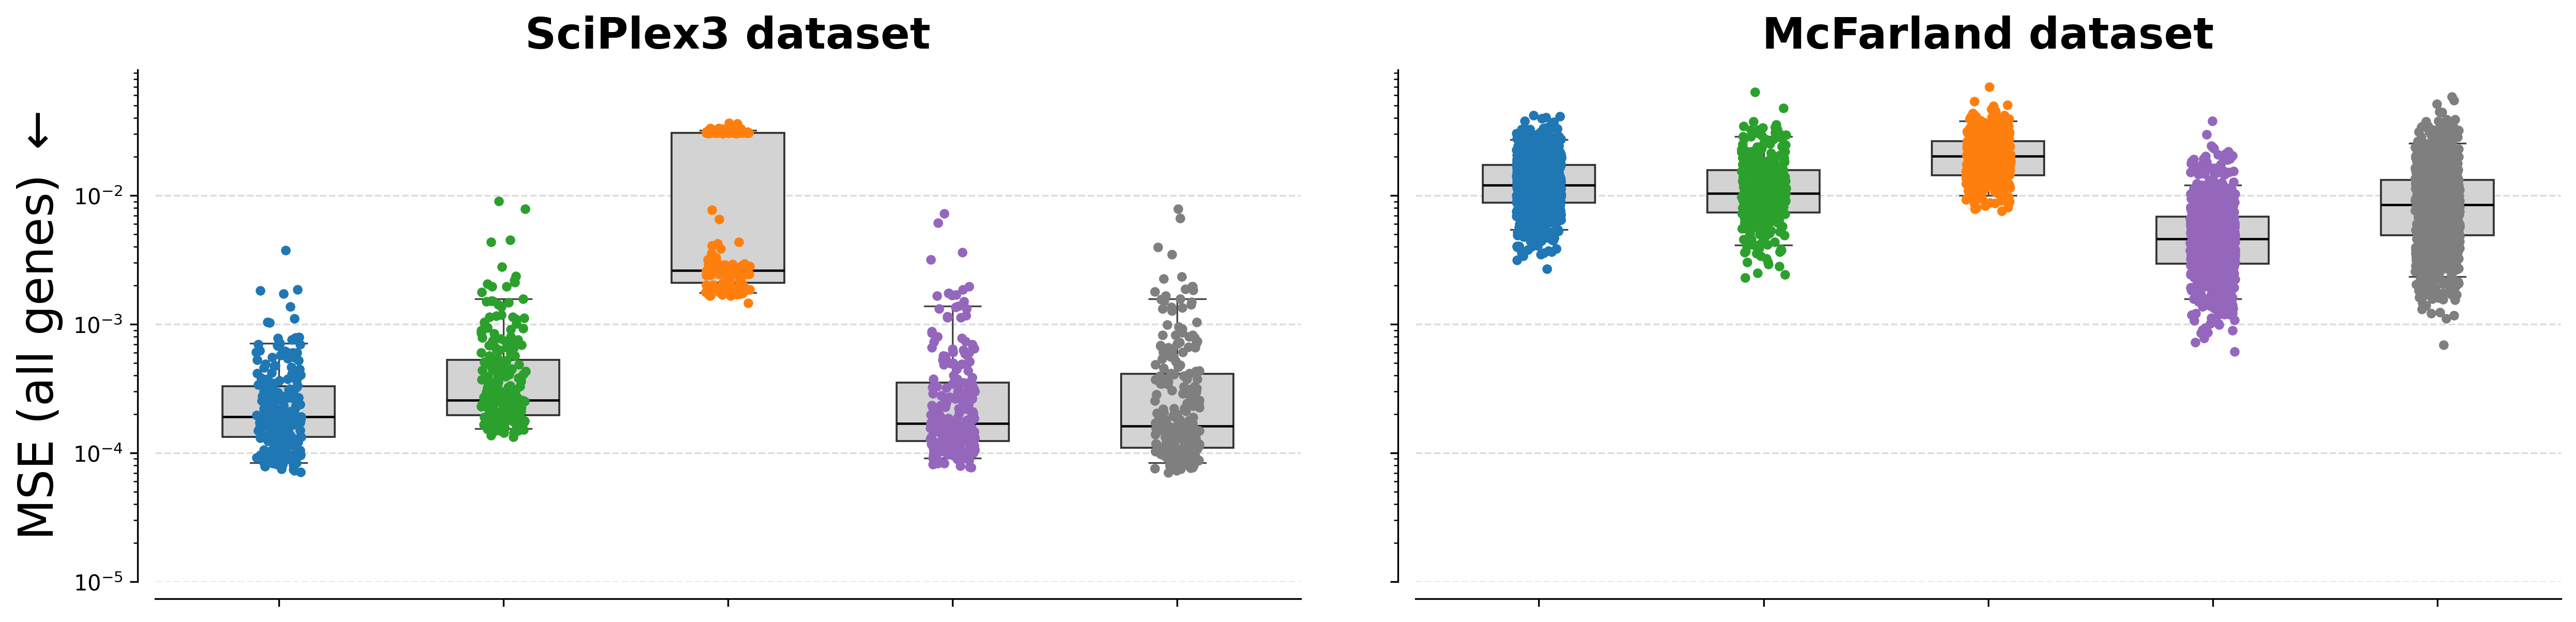

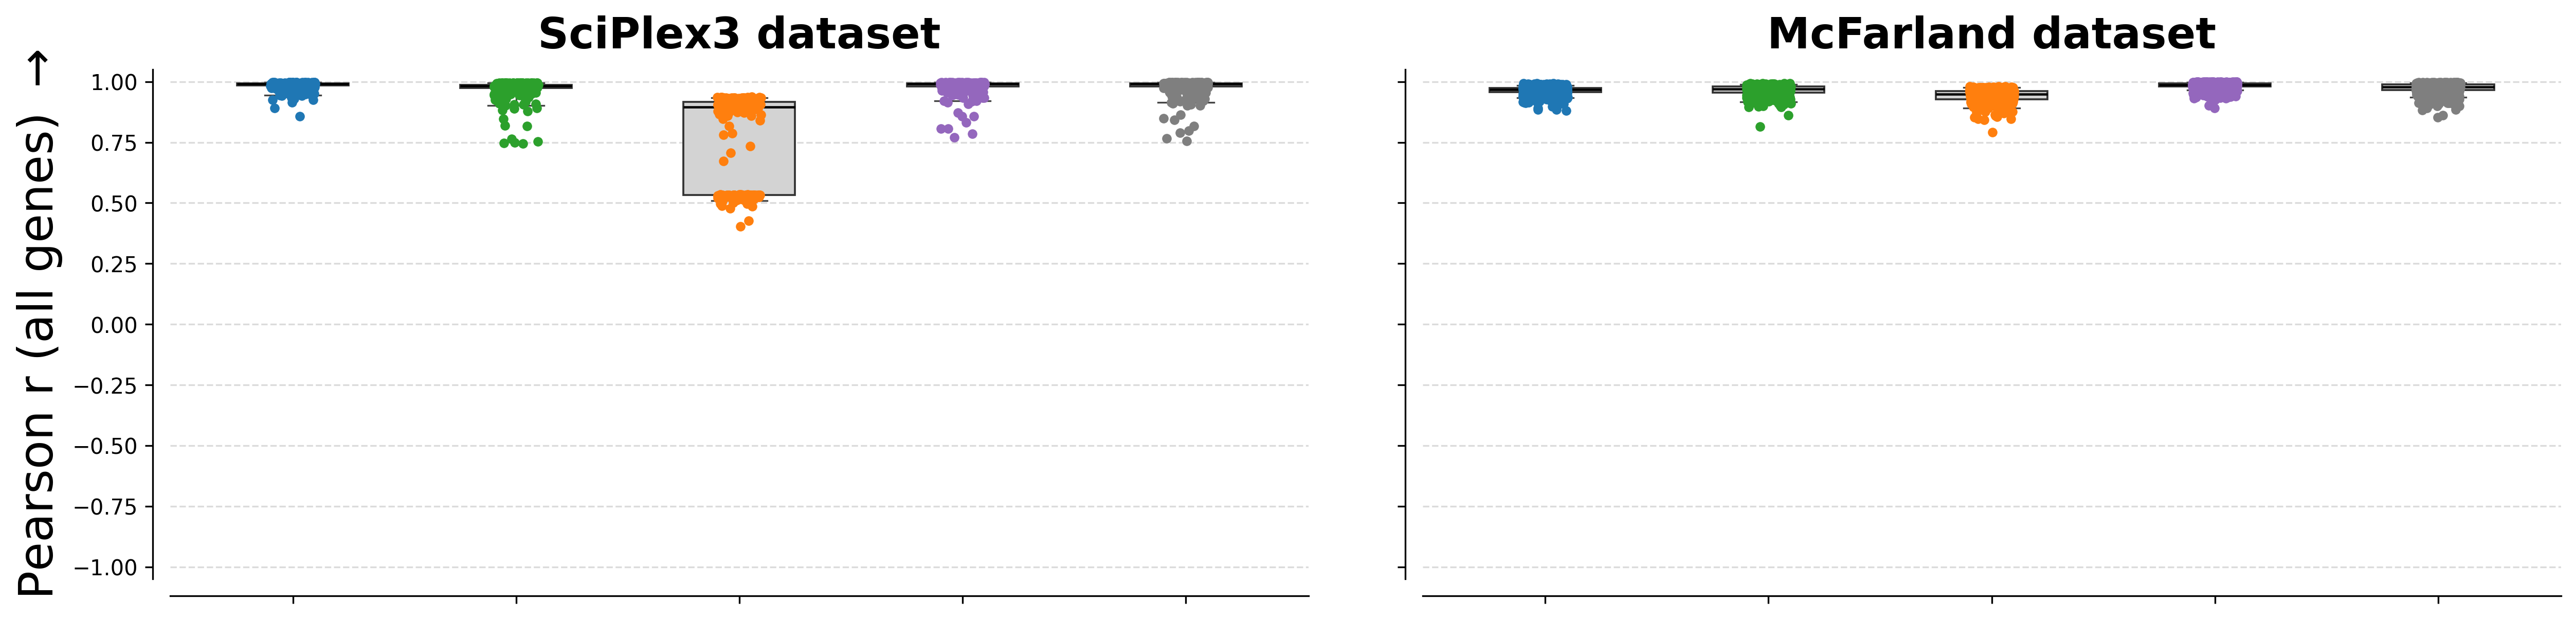

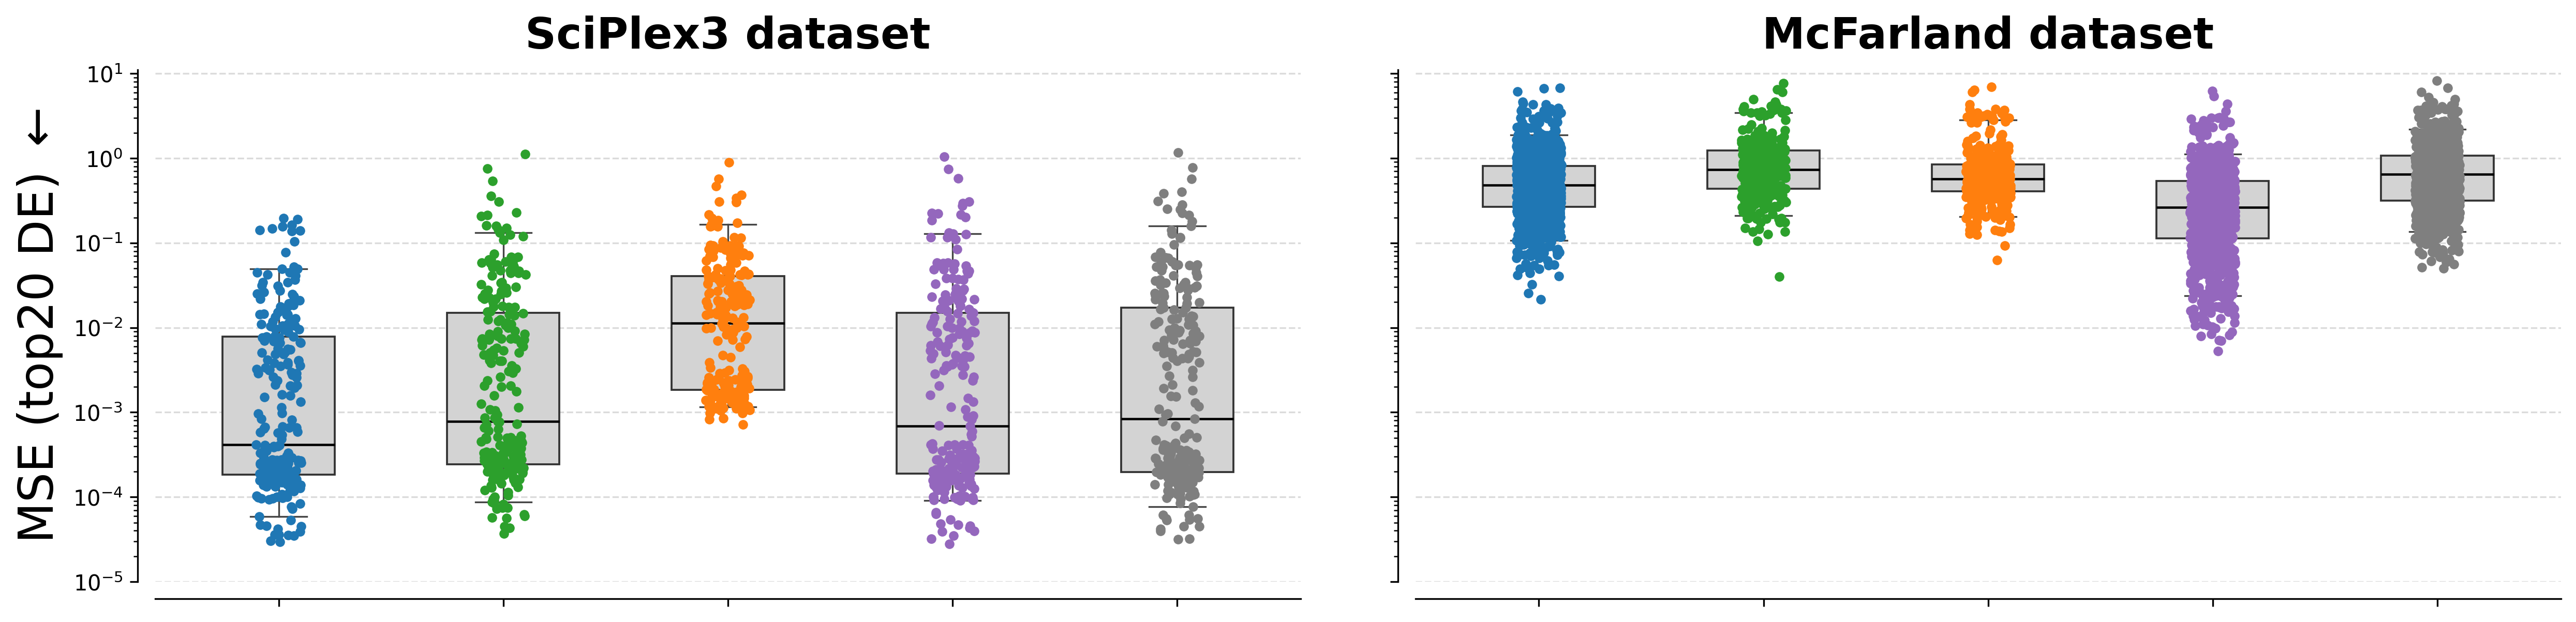

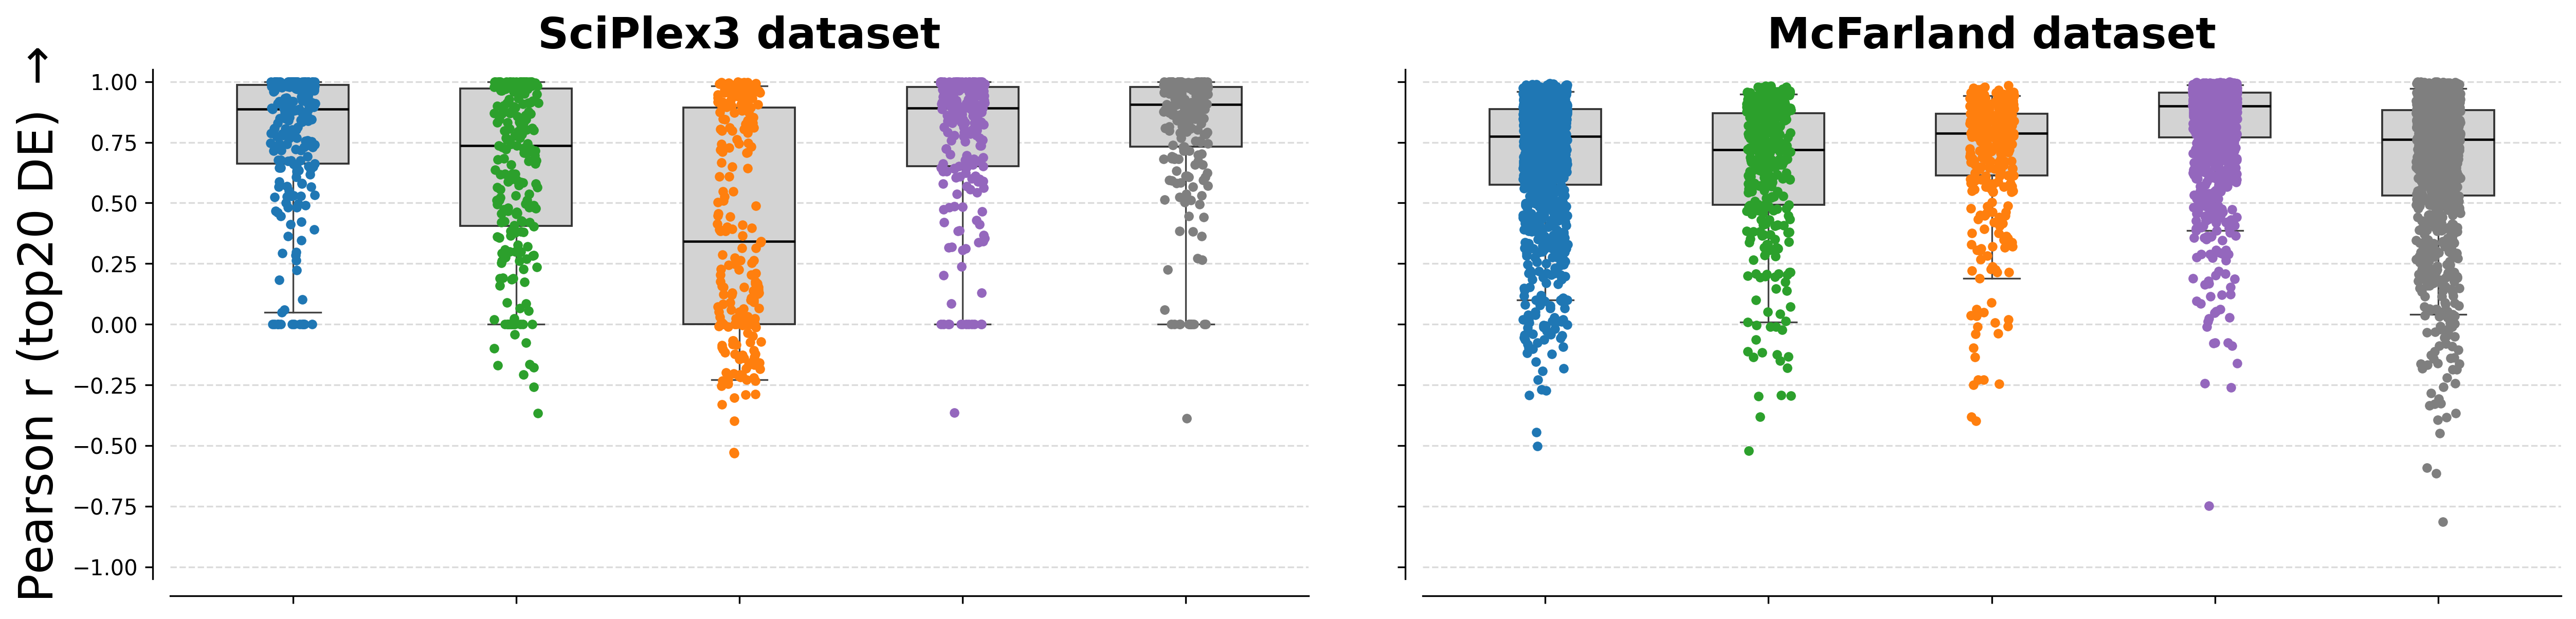

In [9]:
performance_figs = plot_performances_boxplot(
    all_outcomes.dropna(subset=['value']),
    figures_dir,
)

plt.show()


## Systema metrics

Same layout as above: one row per metric, SciPlex | McFarland.


In [10]:
def process_performances_systema(cell_line):
    frames = []
    for stem, model in [
        ('GEARS_systema_outcomes', 'GEARS'),
        ('scfoundation_systema_outcomes', 'scFoundation'),
        ('CPA_systema_outcomes', 'CPA'),
        ('no_effect_systema_outcomes', 'No effect'),
        ('average_effect_systema_outcomes', 'Average effect'),
    ]:
        df = _load_sciplex_outcomes_csv(cell_line, stem)
        if df is None:
            continue
        df['model'] = model
        frames.append(df)

    if not frames:
        raise FileNotFoundError(
            f'No SciPlex Systema outcome files for {cell_line}. '
            'Run evaluate_predictions_sciplex_systema.py first.'
        )

    outcomes = pd.concat(frames, axis=0, ignore_index=True).dropna(subset=['value'])
    outcomes['cell_type_condition'] = outcomes['cell_type'] + '_' + outcomes['condition']
    outcomes['dataset'] = 'SciPlex3 dataset'
    return outcomes


In [11]:
mcf7_outcomes_systema = process_performances_systema('mcf7')
a549_outcomes_systema = process_performances_systema('a549')
k562_outcomes_systema = process_performances_systema('k562')

sciplex_outcomes_systema = pd.concat(
    [mcf7_outcomes_systema, a549_outcomes_systema, k562_outcomes_systema],
    axis=0,
    ignore_index=True,
)
mcfarland_outcomes_systema = process_mcfarland_performances(suffix='_systema')

all_outcomes_systema = pd.concat(
    [sciplex_outcomes_systema, mcfarland_outcomes_systema],
    axis=0,
    ignore_index=True,
)

print('Systema rows per dataset / model:')
print(all_outcomes_systema.groupby(['dataset', 'model']).size().unstack(fill_value=0))


sciplex_outcomes_systema.to_csv(
    os.path.join(results_dir, 'sciplex_all_outcomes_systema.csv'), index=False
)
mcfarland_outcomes_systema.to_csv(
    os.path.join(results_dir, 'mcfarland_all_outcomes_systema.csv'), index=False
)
all_outcomes_systema.to_csv(
    os.path.join(results_dir, 'sciplex_mcfarland_all_outcomes_systema.csv'), index=False
)


Systema rows per dataset / model:
model              Average effect   CPA  GEARS  No effect  scFoundation
dataset                                                                
McFarland dataset            7920  7920   2608       7920          2920
SciPlex3 dataset             1848  1848   1848       1848          1848


Saved u:\nbrouwer1\perturbation_modeling\drug-response-prediction\figures\03_evaluate_predicted_profiles\performance_boxplot_systema_mse.pdf
Saved u:\nbrouwer1\perturbation_modeling\drug-response-prediction\figures\03_evaluate_predicted_profiles\performance_boxplot_systema_pearson_systema.pdf
Saved u:\nbrouwer1\perturbation_modeling\drug-response-prediction\figures\03_evaluate_predicted_profiles\performance_boxplot_systema_pearson_systema_cellline.pdf
Saved u:\nbrouwer1\perturbation_modeling\drug-response-prediction\figures\03_evaluate_predicted_profiles\performance_boxplot_systema_pearson_systema_cellline_de.pdf


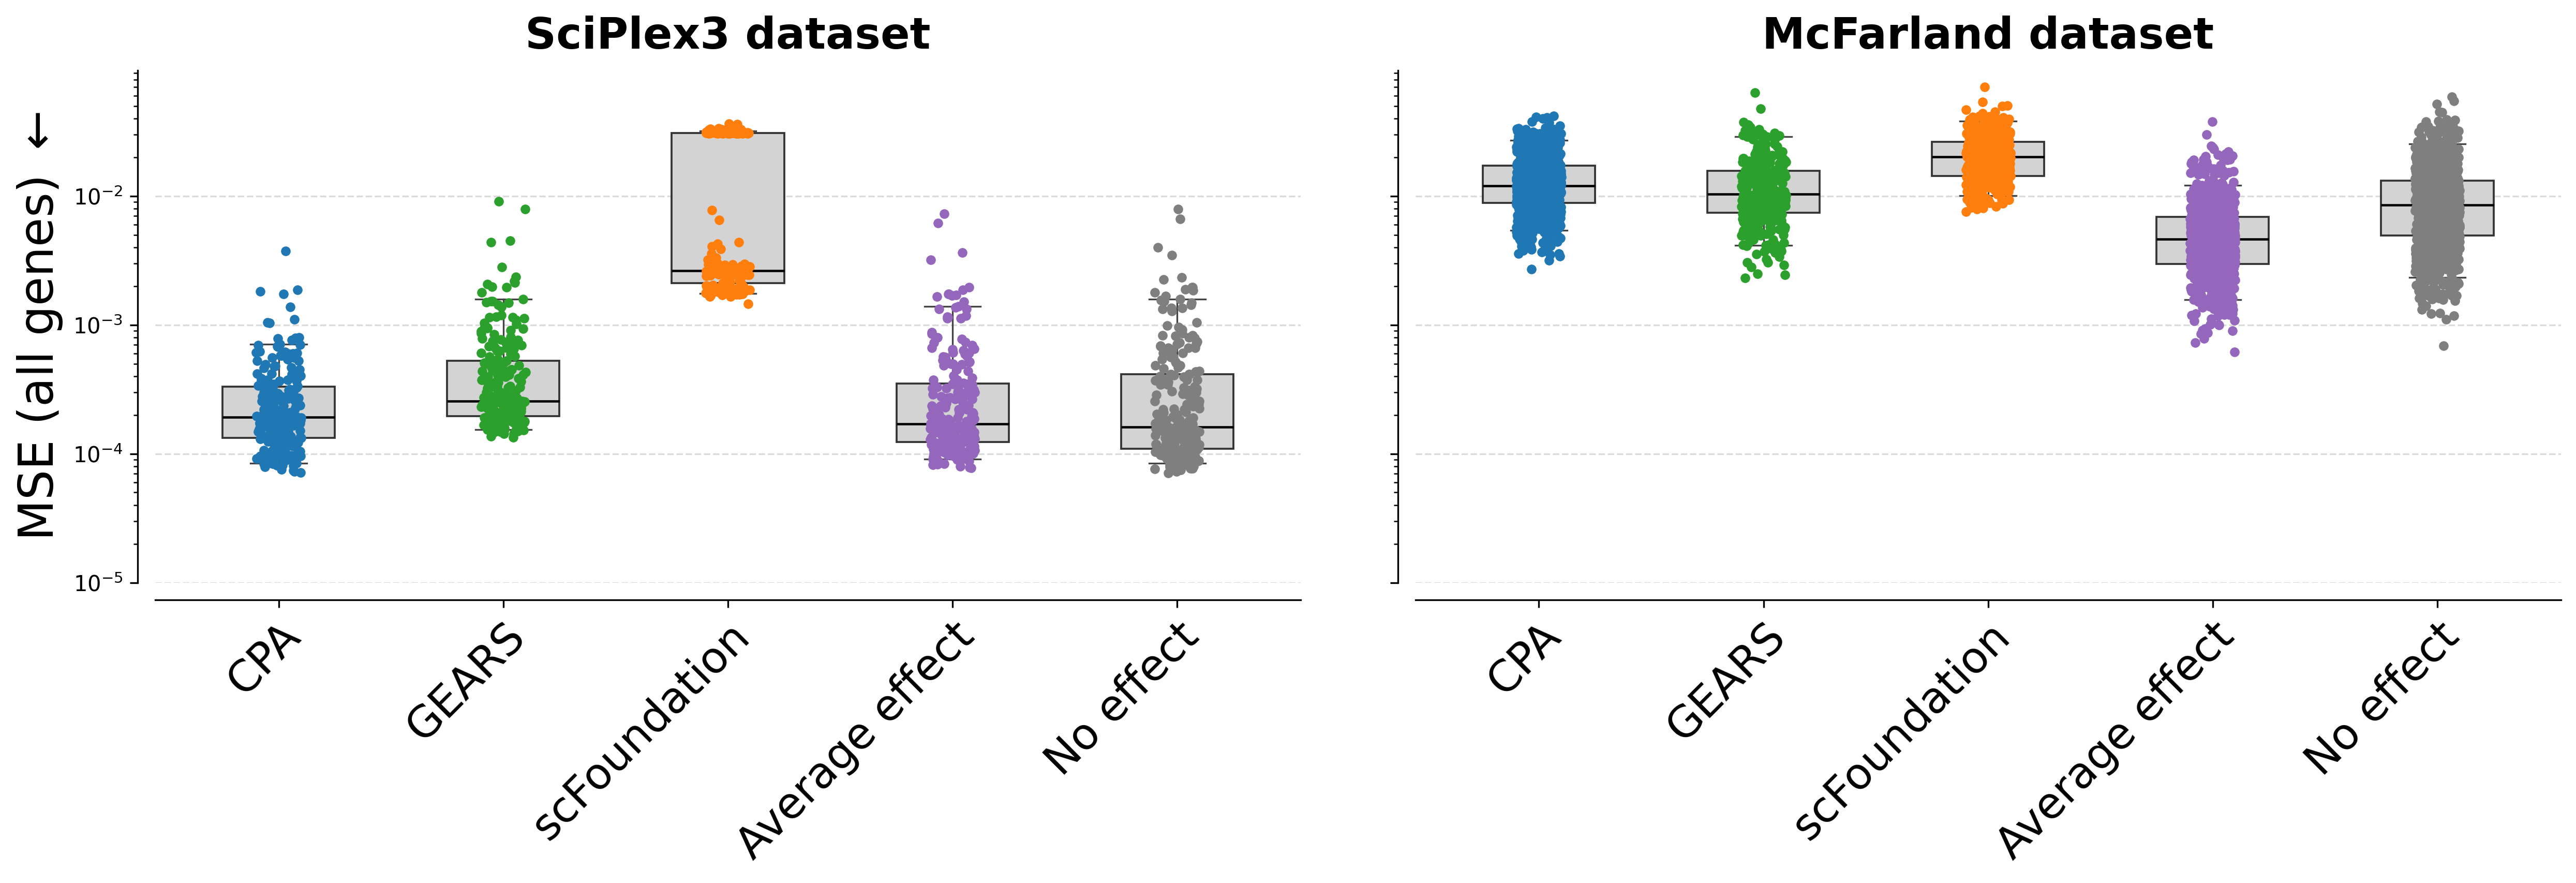

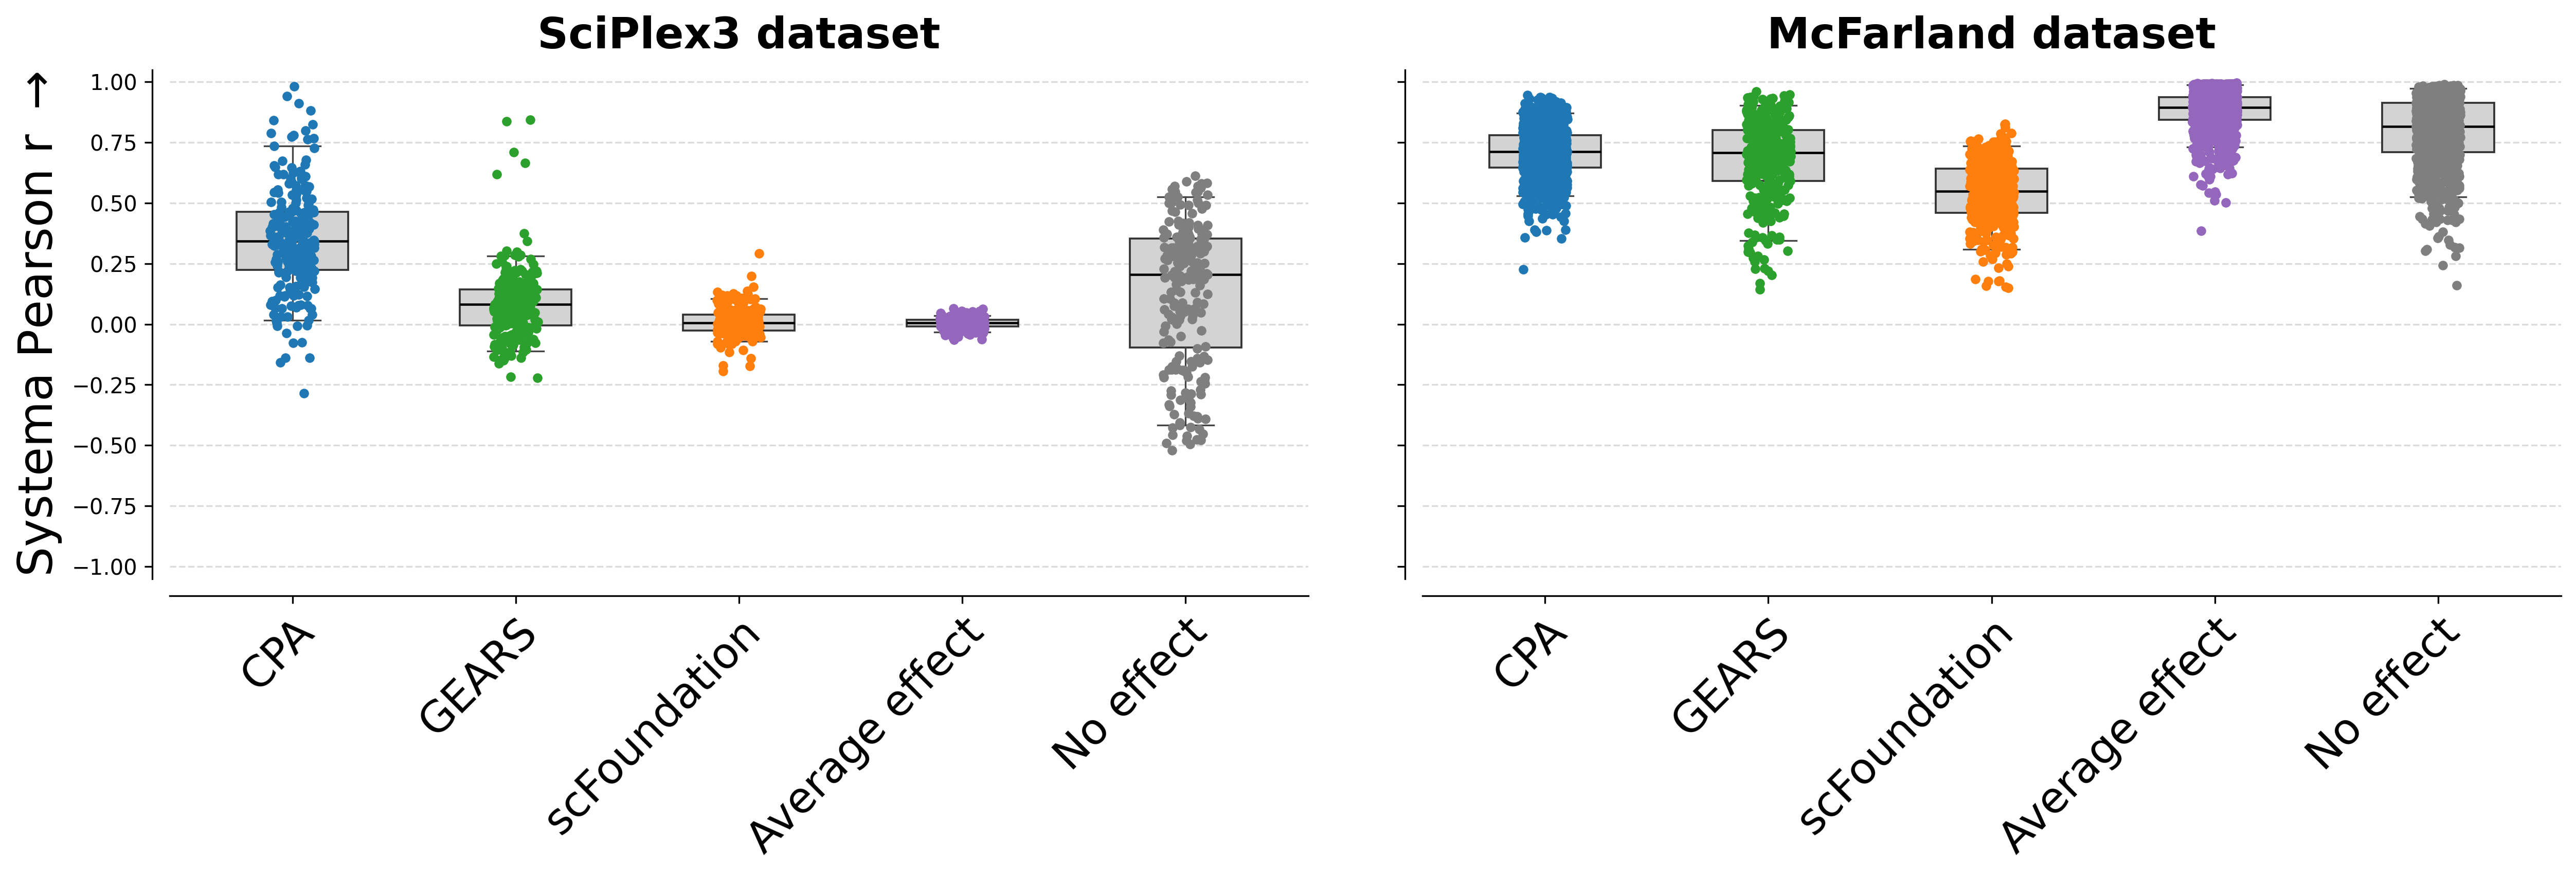

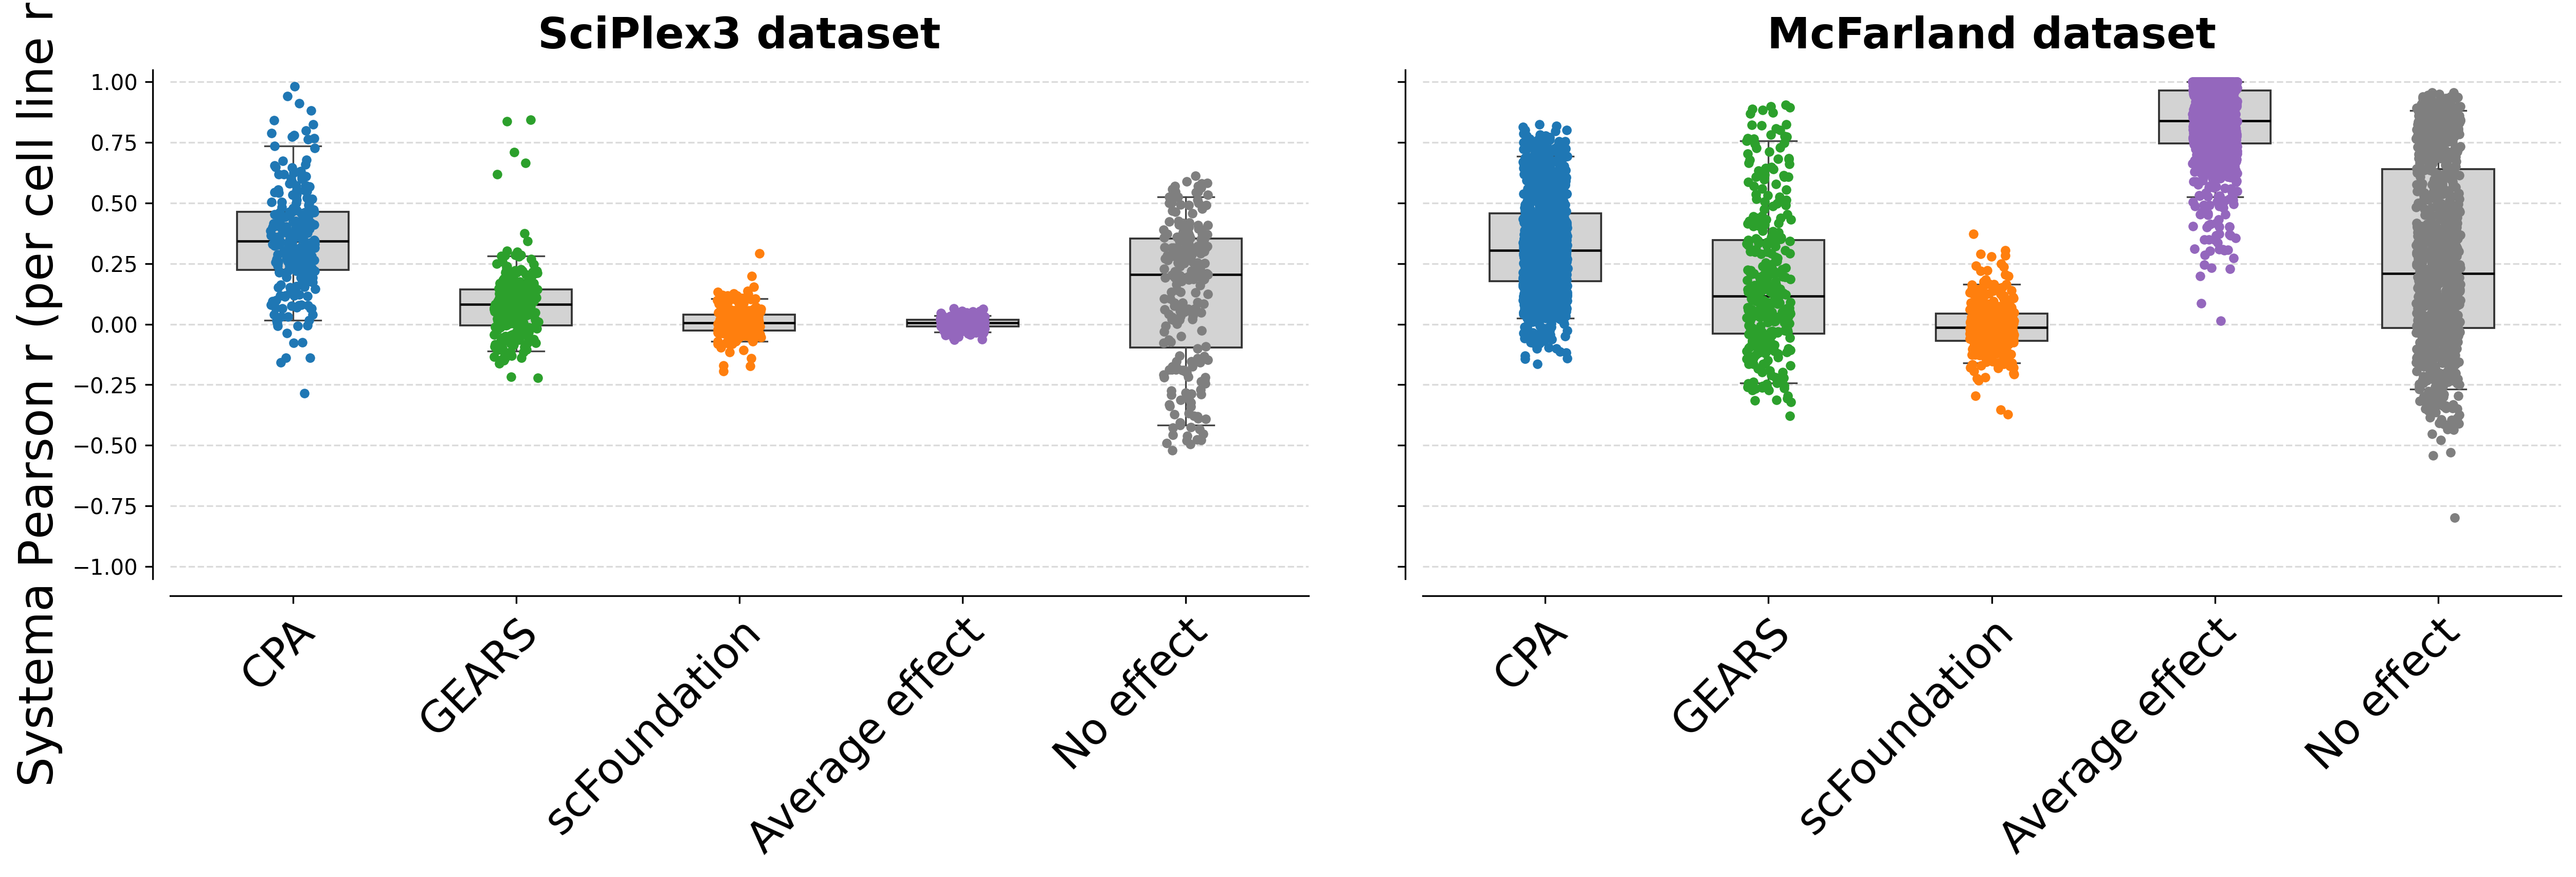

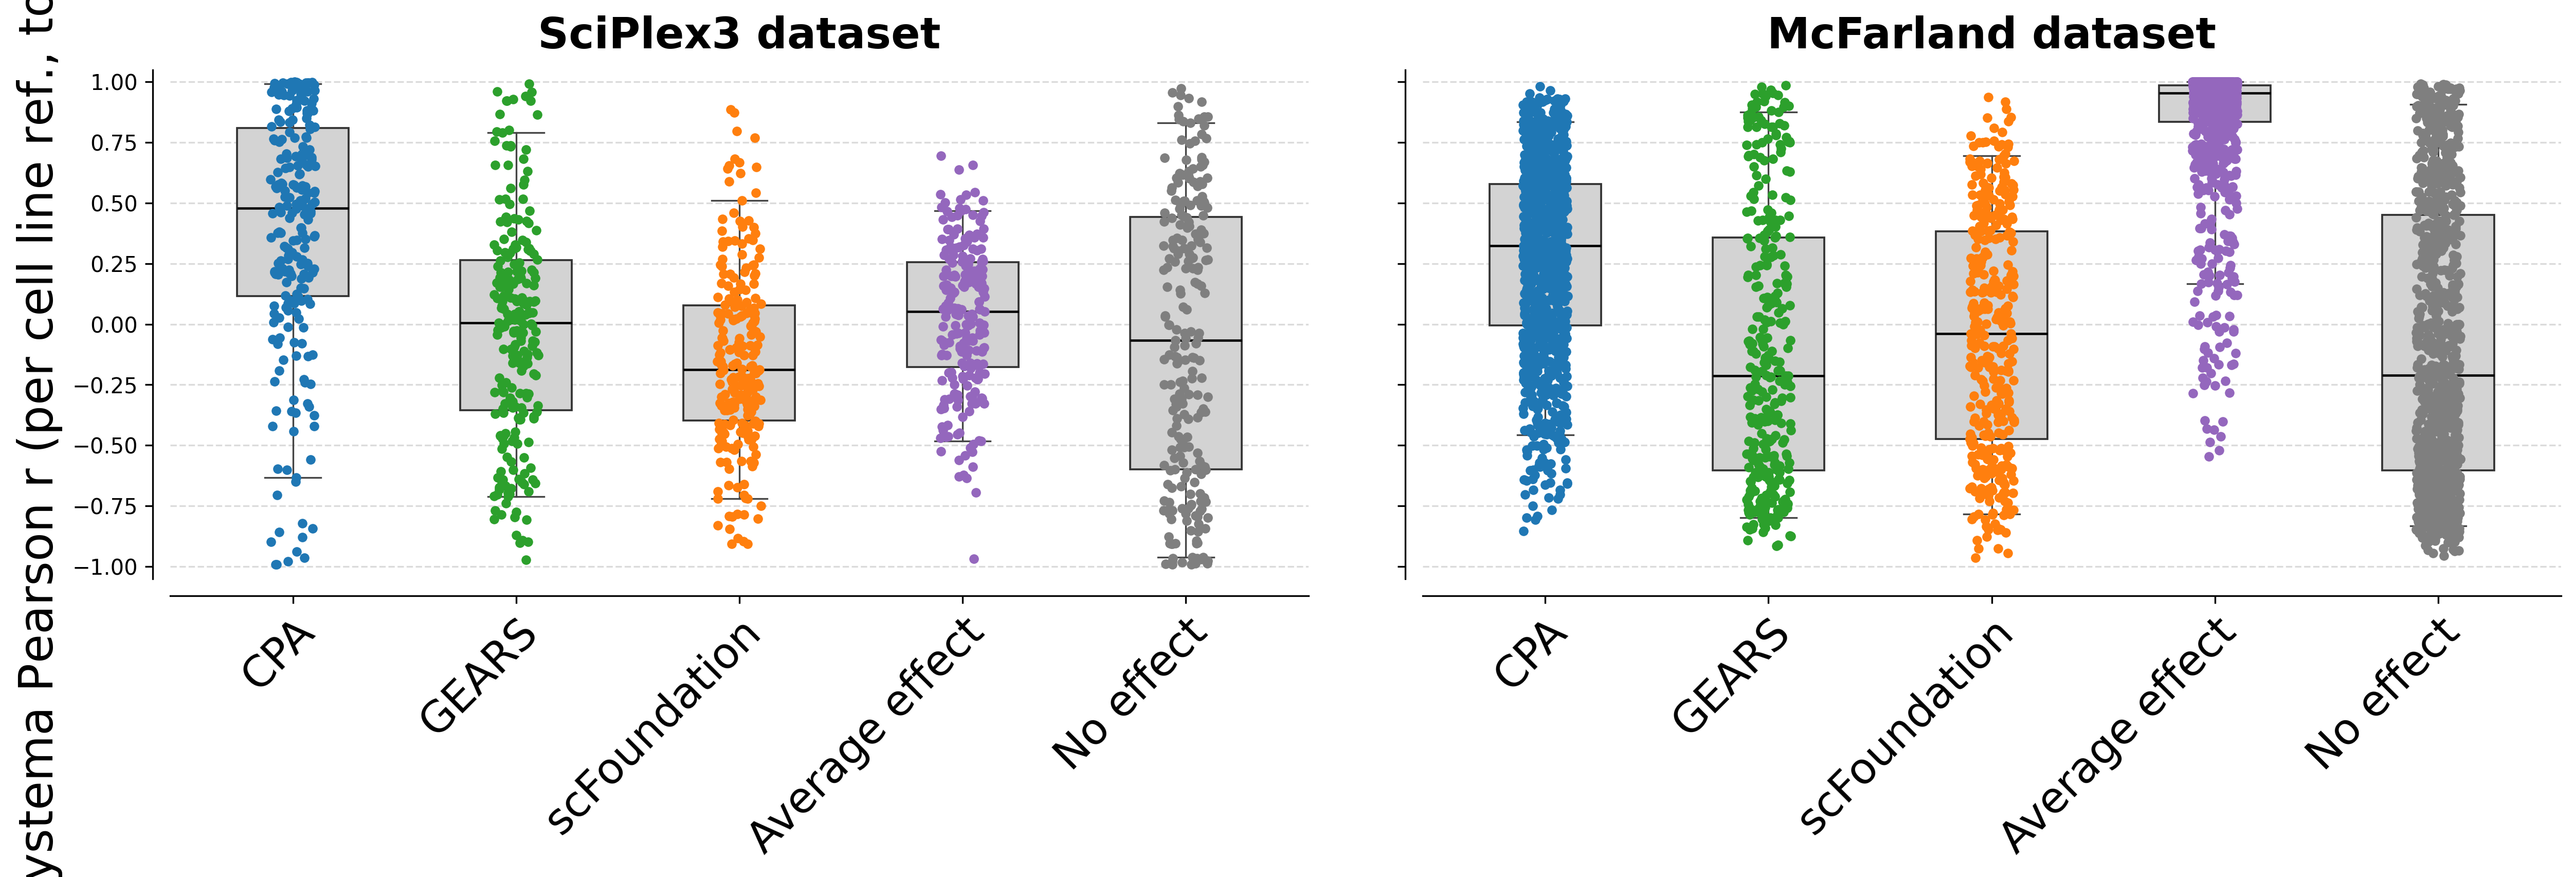

In [12]:
systema_figs = plot_performances_boxplot_systema(
    all_outcomes_systema.dropna(subset=['value']),
    figures_dir,
)
plt.show()


In [18]:
all_outcomes_systema

,condition,metric,value,cell_type,model,cell_type_condition,dataset,cell_line,fold
0,ABL1+ctrl,mse,0.000264,MCF7,GEARS,MCF7_ABL1+ctrl,SciPlex3 dataset,NaN,NaN
1,ALDH2+ctrl,mse,0.000204,MCF7,GEARS,MCF7_ALDH2+ctrl,SciPlex3 dataset,NaN,NaN
2,ALK+ctrl,mse,0.001015,MCF7,GEARS,MCF7_ALK+ctrl,SciPlex3 dataset,NaN,NaN
3,ALOX5+ctrl,mse,0.000207,MCF7,GEARS,MCF7_ALOX5+ctrl,SciPlex3 dataset,NaN,NaN
4,APP+ctrl,mse,0.000200,MCF7,GEARS,MCF7_APP+ctrl,SciPlex3 dataset,NaN,NaN
...,...,...,...,...,...,...,...,...,...
38523,PIK3CA+ctrl,pearson_systema_cellline,1.000000,WM2664,Average effect,WM2664_PIK3CA+ctrl,McFarland dataset,WM2664,4.0
38524,PIK3CA+ctrl,mse_de,0.130685,WM2664,Average effect,WM2664_PIK3CA+ctrl,McFarland dataset,WM2664,4.0
38525,PIK3CA+ctrl,pearson_de,0.874613,WM2664,Average effect,WM2664_PIK3CA+ctrl,McFarland dataset,WM2664,4.0
38526,PIK3CA+ctrl,pearson_systema_de,0.954601,WM2664,Average effect,WM2664_PIK3CA+ctrl,McFarland dataset,WM2664,4.0


In [30]:
# Create a pivot table summarizing the mean values for each model and metric, grouped by dataset
pivot_table = all_outcomes_systema.drop(columns=['cell_line', 'fold']).pivot_table(
    index=['condition', 'cell_type', 'model', 'cell_type_condition', 'dataset'],
    columns='metric',
    values='value',
)
pivot_table = pivot_table.reset_index()

# Only take the median over the numeric variables
numeric_cols = pivot_table.select_dtypes(include=[np.number]).columns
group_cols = ['model', 'dataset']
pivot_table_avg = (
    pivot_table[group_cols + list(numeric_cols)]
    .groupby(group_cols)
    .median()
    .reset_index()
)

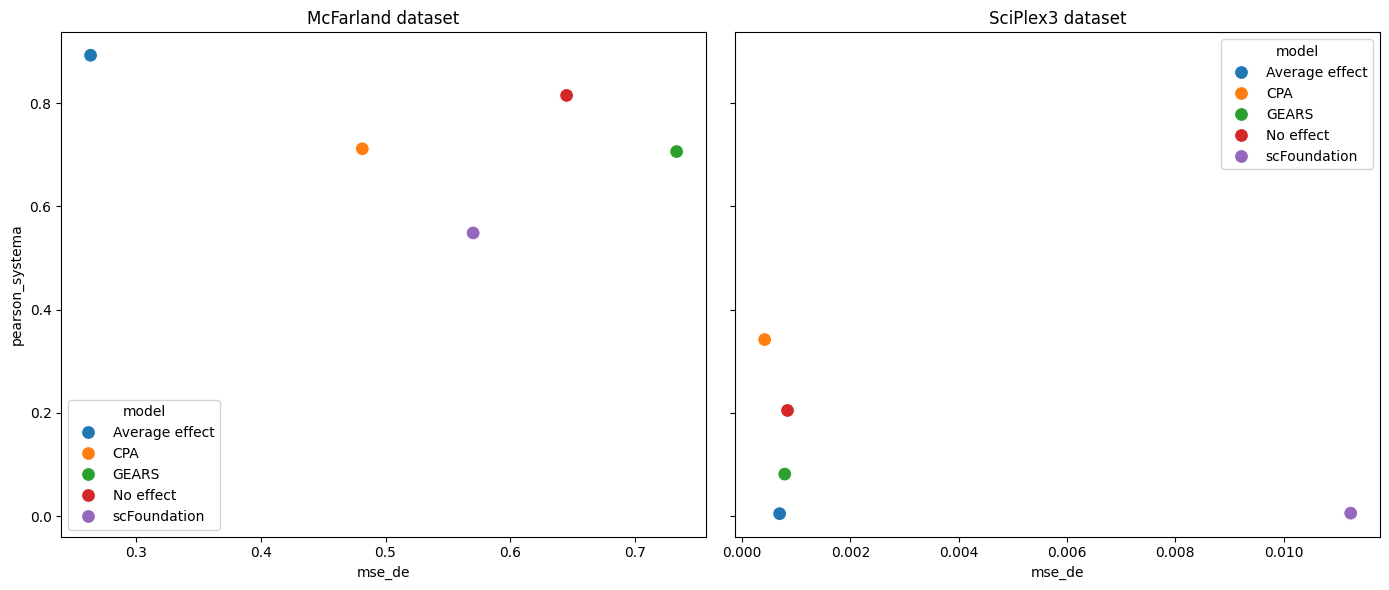

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

datasets = pivot_table_avg['dataset'].unique()
for ax, dataset in zip(axes, datasets):
    sns.scatterplot(
        data=pivot_table_avg[pivot_table_avg['dataset'] == dataset], 
        x='mse_de', 
        y='pearson_systema', 
        hue='model', 
        s=100,
        ax=ax
    )
    ax.set_title(dataset)
    ax.set_xlabel('mse_de')
    ax.set_ylabel('pearson_systema')

plt.tight_layout()